In [2]:
!pip install pytorch-lightning

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install scikit-learn imbalanced-learn matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

ROOT = "../fiot_highway2-main"        # folder containing data/ and train.txt/test.txt
TRAIN_TXT = os.path.join(ROOT, "train.txt")
TEST_TXT  = os.path.join(ROOT, "test.txt")

NUM_CLASSES = 9
INPUT_SHAPE = (512, 243)   # (H, W) for each PSD

# For speed / memory, we can cap how many samples we load
MAX_TRAIN_SAMPLES = 5000   # adjust as needed
MAX_TEST_SAMPLES  = 2000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [5]:
def load_txt_list(txt_path):
    """
    txt file format: relative_path label
    returns: list of (full_path, label)
    """
    entries = np.loadtxt(txt_path, dtype=str).tolist()
    if isinstance(entries[0], str):
        entries = [entries]

    pairs = []
    for rel_path, label_str in entries:
        full_path = os.path.join(ROOT, rel_path)
        pairs.append((full_path, int(label_str)))
    return pairs


def load_psd_dataset(pairs, max_samples=None):
    """
    pairs: list of (full_path, label)
    max_samples: optional cap for how many to load (random subset)
    returns: X (N, H, W), y (N,)
    """
    if max_samples is not None and max_samples < len(pairs):
        indices = np.random.choice(len(pairs), size=max_samples, replace=False)
        pairs = [pairs[i] for i in indices]

    X_list = []
    y_list = []

    for full_path, label in pairs:
        mat = np.load(full_path)  # (512, 243)
        # per-sample normalization
        mat = (mat - mat.mean()) / (mat.std() + 1e-6)
        X_list.append(mat)
        y_list.append(label)

    X = np.stack(X_list)  # (N, 512, 243)
    y = np.array(y_list)
    return X, y


def plot_class_distribution(labels, title):
    counts = Counter(labels)
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]

    plt.figure(figsize=(7, 4))
    plt.bar(classes, values)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(classes)
    plt.tight_layout()
    plt.show()

Total train examples listed: 12915
Total test  examples listed: 3296
Loaded train shape: (5000, 512, 243) labels shape: (5000,)
Loaded test shape:  (2000, 512, 243) labels shape: (2000,)


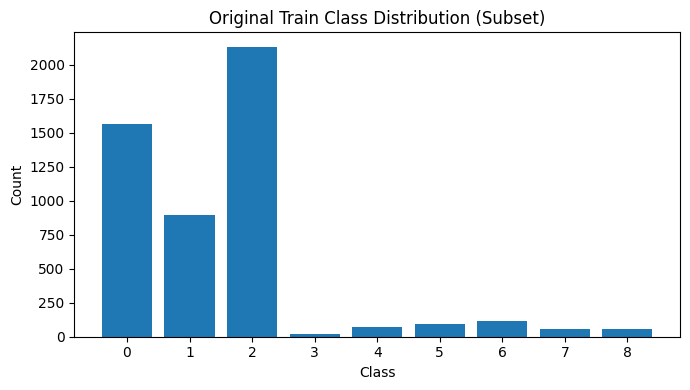

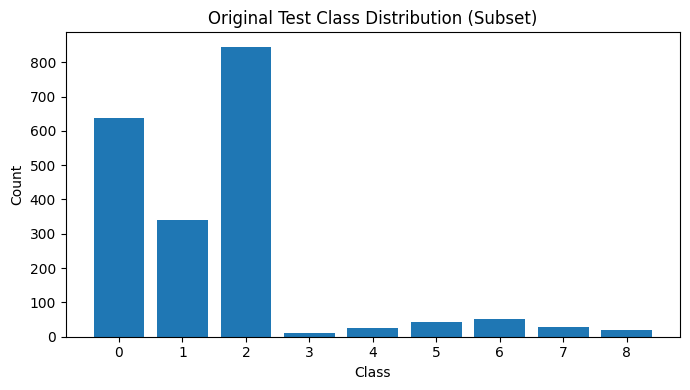

In [6]:
# Load file lists
train_pairs = load_txt_list(TRAIN_TXT)
test_pairs  = load_txt_list(TEST_TXT)

print("Total train examples listed:", len(train_pairs))
print("Total test  examples listed:", len(test_pairs))

# Load subsets into memory with normalization
X_train, y_train = load_psd_dataset(train_pairs, max_samples=MAX_TRAIN_SAMPLES)
X_test,  y_test  = load_psd_dataset(test_pairs,  max_samples=MAX_TEST_SAMPLES)

print("Loaded train shape:", X_train.shape, "labels shape:", y_train.shape)
print("Loaded test shape: ", X_test.shape,  "labels shape:", y_test.shape)

# Plot original distributions
plot_class_distribution(y_train.tolist(), "Original Train Class Distribution (Subset)")
plot_class_distribution(y_test.tolist(),  "Original Test Class Distribution (Subset)")

Flattened train shape: (5000, 124416)
Flattened test shape:  (2000, 124416)
Train subset: (4000, 124416) Val subset: (1000, 124416)


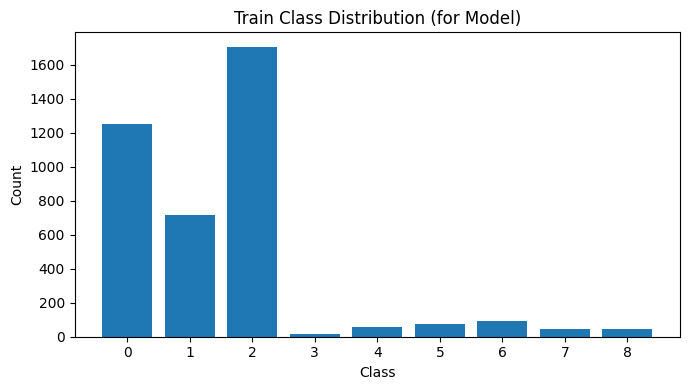

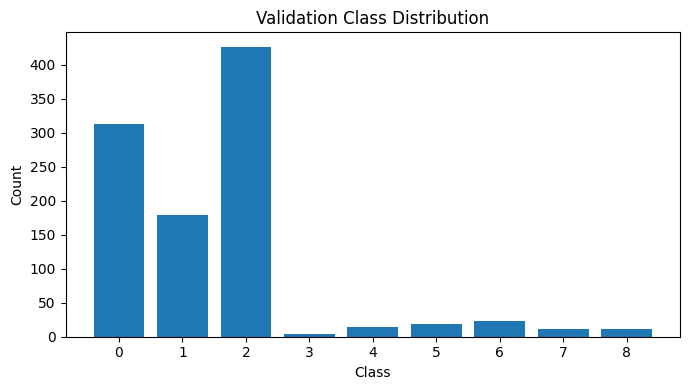

In [7]:
# Flatten each PSD: (N, 512, 243) -> (N, 512*243)
N_train, H, W = X_train.shape
N_test,  H2, W2 = X_test.shape
assert (H, W) == (H2, W2) == INPUT_SHAPE

X_train_flat = X_train.reshape(N_train, H * W)
X_test_flat  = X_test.reshape(N_test,  H * W)

print("Flattened train shape:", X_train_flat.shape)
print("Flattened test shape: ", X_test_flat.shape)

# Further split train into train/val for monitoring performance
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_flat,
    y_train,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_train,
)

print("Train subset:", X_tr.shape, "Val subset:", X_val.shape)
plot_class_distribution(y_tr.tolist(), "Train Class Distribution (for Model)")
plot_class_distribution(y_val.tolist(), "Validation Class Distribution")

In [8]:
from sklearn.decomposition import PCA

# Reduce dimensionality BEFORE SMOTE
N_COMPONENTS_SMOTE = 64  # safe dimension

print("Running PCA before SMOTE...")

pca_for_smote = PCA(n_components=N_COMPONENTS_SMOTE, random_state=RANDOM_SEED)
X_tr_reduced = pca_for_smote.fit_transform(X_tr)

print("Reduced training shape:", X_tr_reduced.shape)

Running PCA before SMOTE...
Reduced training shape: (4000, 64)


Before SMOTE (train): Counter({np.int64(2): 1706, np.int64(0): 1254, np.int64(1): 716, np.int64(6): 94, np.int64(5): 75, np.int64(4): 55, np.int64(7): 43, np.int64(8): 43, np.int64(3): 14})
After SMOTE (train): Counter({np.int64(0): 1706, np.int64(1): 1706, np.int64(6): 1706, np.int64(2): 1706, np.int64(4): 1706, np.int64(5): 1706, np.int64(7): 1706, np.int64(8): 1706, np.int64(3): 1706})


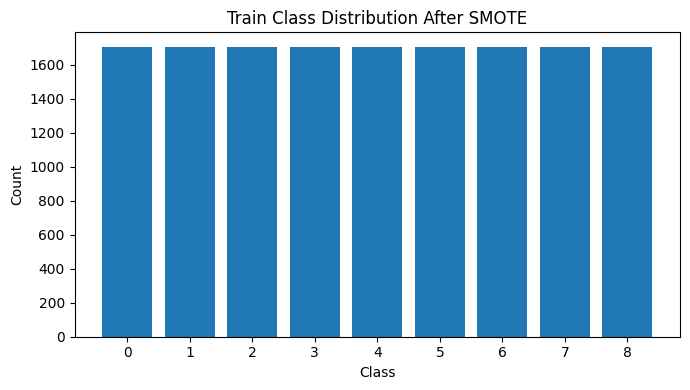

In [9]:
print("Before SMOTE (train):", Counter(y_tr))

smote = SMOTE(random_state=RANDOM_SEED)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_reduced, y_tr)

print("After SMOTE (train):", Counter(y_tr_smote))

plot_class_distribution(y_tr_smote.tolist(), "Train Class Distribution After SMOTE")

In [10]:
# Fit a Logistic Regression classifier on the SMOTE-balanced, PCA-reduced data
clf = LogisticRegression(
    max_iter=300,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)

clf.fit(X_tr_smote, y_tr_smote)


/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'multinomial'


In [11]:
X_val_reduced = pca_for_smote.transform(X_val)
X_test_reduced = pca_for_smote.transform(X_test_flat)

y_val_pred = clf.predict(X_val_reduced)
y_test_pred = clf.predict(X_test_reduced)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))


Validation accuracy: 0.547
Test accuracy: 0.5655


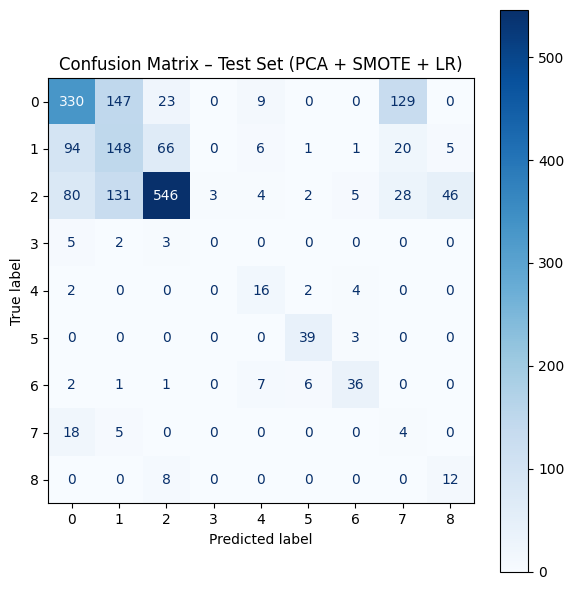

In [12]:
cm = confusion_matrix(y_test, y_test_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Test Set (PCA + SMOTE + LR)")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning

# optionally silence convergence warnings so they don't spam the notebook
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ------------------------
# BASELINE (NO SMOTE)
# ------------------------

N_COMPONENTS = 64  # same as for SMOTE PCA; you can drop to 32 if you want faster convergence

pca_baseline = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_tr_base = pca_baseline.fit_transform(X_tr)
X_val_base = pca_baseline.transform(X_val)
X_test_base = pca_baseline.transform(X_test_flat)

baseline_clf = LogisticRegression(
    max_iter=2000,           # <- increased from 300
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)

print("Fitting BASELINE model (no SMOTE)...")
baseline_clf.fit(X_tr_base, y_tr)

y_tr_pred_base  = baseline_clf.predict(X_tr_base)
y_val_pred_base = baseline_clf.predict(X_val_base)
y_test_pred_base = baseline_clf.predict(X_test_base)

acc_train_base = accuracy_score(y_tr, y_tr_pred_base)
acc_val_base   = accuracy_score(y_val, y_val_pred_base)
acc_test_base  = accuracy_score(y_test, y_test_pred_base)

# ------------------------
# SMOTE MODEL
# ------------------------
# assumes you already did:
#   pca_for_smote = PCA(...)
#   X_tr_reduced = pca_for_smote.fit_transform(X_tr)
#   X_tr_smote, y_tr_smote = smote.fit_resample(X_tr_reduced, y_tr)
#   X_val_reduced = pca_for_smote.transform(X_val)
#   X_test_reduced = pca_for_smote.transform(X_test_flat)

smote_clf = LogisticRegression(
    max_iter=2000,           # <- also allow more iterations
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)

print("Fitting SMOTE model (PCA + SMOTE)...")
smote_clf.fit(X_tr_smote, y_tr_smote)

y_tr_pred_smote  = smote_clf.predict(X_tr_reduced)       # use original reduced train (no resample)
y_val_pred_smote = smote_clf.predict(X_val_reduced)
y_test_pred_smote = smote_clf.predict(X_test_reduced)

acc_train_smote = accuracy_score(y_tr, y_tr_pred_smote)
acc_val_smote   = accuracy_score(y_val, y_val_pred_smote)
acc_test_smote  = accuracy_score(y_test, y_test_pred_smote)

# ------------------------
# BUILD COMPARISON TABLE
# ------------------------

results_table = pd.DataFrame({
    "Metric": ["Train Accuracy", "Validation Accuracy", "Test Accuracy"],
    "Baseline (No SMOTE)": [
        acc_train_base,
        acc_val_base,
        acc_test_base
    ],
    "With SMOTE": [
        acc_train_smote,
        acc_val_smote,
        acc_test_smote
    ]
})

print("=== Accuracy Comparison ===")
print(results_table.to_string(index=False))


Fitting BASELINE model (no SMOTE)...


/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fitting SMOTE model (PCA + SMOTE)...


/usr/local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Accuracy Comparison ===
             Metric  Baseline (No SMOTE)  With SMOTE
     Train Accuracy               0.6910     0.56425
Validation Accuracy               0.6570     0.57300
      Test Accuracy               0.6735     0.57050
